In [3]:
# training rough model

import numpy as np
from tensorflow.keras import layers, models
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [4]:
EPOCHS = 20
BATCH_SIZE = 4

X_DIR = "../data/processed/patches/X.npy"
Y_DIR = "../data/processed/patches/Y.npy"

X = np.load(X_DIR).astype(np.float32)
Y = np.load(Y_DIR).astype(np.float32)

print("X shape:", X.shape, "dtype:", X.dtype, "min/max:", X.min(), X.max())
print("Y shape:", Y.shape, "dtype:", Y.dtype, "min/max:", Y.min(), Y.max())

print("Foreground pixel ratio:", np.mean(Y))

X shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Foreground pixel ratio: 0.14651524


In [5]:
# simple unet model
# inputs → encoder → bottleneck → decoder → sigmoid mask

def build_unet(input_shape=(256,256,1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.UpSampling2D()(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

In [6]:
# intensity augmentation to image only
# same geometric augmentation to image and mask
def augment_patch(image, mask):

    if random.random() < 0.5:
        image = np.flip(image, axis=1)
        mask = np.flip(mask, axis=1)

    if random.random() < 0.5:
        image = np.flip(image, axis=0)
        mask = np.flip(mask, axis=0)

    # 90 deg rotation
    k = random.choice([0, 1, 2, 3])
    image = np.rot90(image, k)
    mask = np.rot90(mask, k)

    # Brightness shift — image only
    if random.random() < 0.5:
        shift = random.uniform(-0.08, 0.08)
        image = image + shift

    # Contrast adjustment — image only
    if random.random() < 0.5:
        factor = random.uniform(0.85, 1.15)
        image = (image - image.mean()) * factor + image.mean()

    # Clip image back to valid range
    image = np.clip(image, 0, 1)

    # Ensure mask stays binary
    mask = (mask > 0.5).astype(np.float32)

    return image.astype(np.float32), mask.astype(np.float32)

In [7]:
def augment_dataset(X_train, Y_train, augment_factor=3):
    X_aug = [X_train]
    Y_aug = [Y_train]

    for _ in range(augment_factor):
        augmented_images = []
        augmented_masks = []

        for img, msk in zip(X_train, Y_train):
            img_aug, msk_aug = augment_patch(img, msk)
            augmented_images.append(img_aug)
            augmented_masks.append(msk_aug)

        X_aug.append(np.array(augmented_images, dtype=np.float32))
        Y_aug.append(np.array(augmented_masks, dtype=np.float32))

    X_aug = np.concatenate(X_aug, axis=0)
    Y_aug = np.concatenate(Y_aug, axis=0)

    return X_aug, Y_aug

In [8]:

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Before augmentation:")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

X_train_aug, Y_train_aug = augment_dataset(
    X_train,
    Y_train,
    augment_factor=3
)

print("\nAfter augmentation:")
print("X_train_aug:", X_train_aug.shape)
print("Y_train_aug:", Y_train_aug.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

Before augmentation:
X_train: (108, 256, 256, 1)
Y_train: (108, 256, 256, 1)
X_val: (28, 256, 256, 1)
Y_val: (28, 256, 256, 1)

After augmentation:
X_train_aug: (432, 256, 256, 1)
Y_train_aug: (432, 256, 256, 1)
X_val: (28, 256, 256, 1)
Y_val: (28, 256, 256, 1)


In [9]:

def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    weights = y_true * 1.5 + 1
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(weights * bce)

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [10]:
def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    weights = y_true * 1.5 + 1
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(weights * bce)

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [11]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [12]:
model = build_unet()

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=combined_loss,
              metrics=[dice_coef, iou_coef])


In [13]:
history = model.fit(
    X_train_aug,
    Y_train_aug,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - dice_coef: 0.2010 - iou_coef: 0.1129 - loss: 1.5692 - val_dice_coef: 0.2055 - val_iou_coef: 0.1157 - val_loss: 1.5724
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 225ms/step - dice_coef: 0.1958 - iou_coef: 0.1099 - loss: 1.5568 - val_dice_coef: 0.1945 - val_iou_coef: 0.1087 - val_loss: 1.5748
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - dice_coef: 0.1957 - iou_coef: 0.1097 - loss: 1.5531 - val_dice_coef: 0.2006 - val_iou_coef: 0.1125 - val_loss: 1.5646
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - dice_coef: 0.1962 - iou_coef: 0.1099 - loss: 1.5517 - val_dice_coef: 0.1929 - val_iou_coef: 0.1077 - val_loss: 1.5746
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - dice_coef: 0.1953 - iou_coef: 0.1095 - loss: 1.5532 - val_dice_coef: 0.1958 - val_iou_coef: 0.1095 - val_loss: 1.5732
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - dice_coef: 0.1949 - iou_coef: 0.1090 - loss: 1.5543 - val_dice_coef:

In [14]:
preds_val = model.predict(X_val)

print("Prediction min:", preds_val.min())
print("Prediction max:", preds_val.max())
print("Prediction mean:", preds_val.mean())
print("Ground truth foreground ratio:", Y_val.mean())

def dice_at_threshold(y_true, y_pred, threshold):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    return (2 * intersection + 1) / (np.sum(y_true) + np.sum(y_pred_bin) + 1)

for t in np.arange(0.25, 0.50, 0.025):
    d = dice_at_threshold(Y_val, preds_val, t)
    fg = (preds_val > t).mean()
    print(f"Threshold {t:.3f} | Dice: {d:.4f} | Pred foreground: {fg:.4f}")
    
# for t in [0.2, 0.3, 0.4, 0.5]:
#     print(f"Foreground ratio at threshold {t}:", (preds_val > t).mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
Prediction min: 0.14945959
Prediction max: 0.47106305
Prediction mean: 0.3104652
Ground truth foreground ratio: 0.15308926
Threshold 0.250 | Dice: 0.2654 | Pred foreground: 0.9813
Threshold 0.275 | Dice: 0.2627 | Pred foreground: 0.9394
Threshold 0.300 | Dice: 0.2478 | Pred foreground: 0.7885
Threshold 0.325 | Dice: 0.1500 | Pred foreground: 0.1637
Threshold 0.350 | Dice: 0.0207 | Pred foreground: 0.0115
Threshold 0.375 | Dice: 0.0115 | Pred foreground: 0.0060
Threshold 0.400 | Dice: 0.0006 | Pred foreground: 0.0007
Threshold 0.425 | Dice: 0.0002 | Pred foreground: 0.0003
Threshold 0.450 | Dice: 0.0000 | Pred foreground: 0.0000
Threshold 0.475 | Dice: 0.0000 | Pred foreground: 0.0000


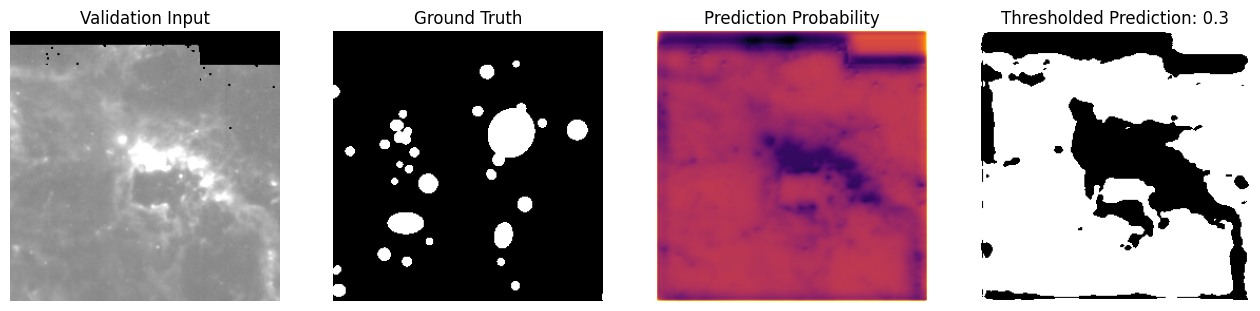

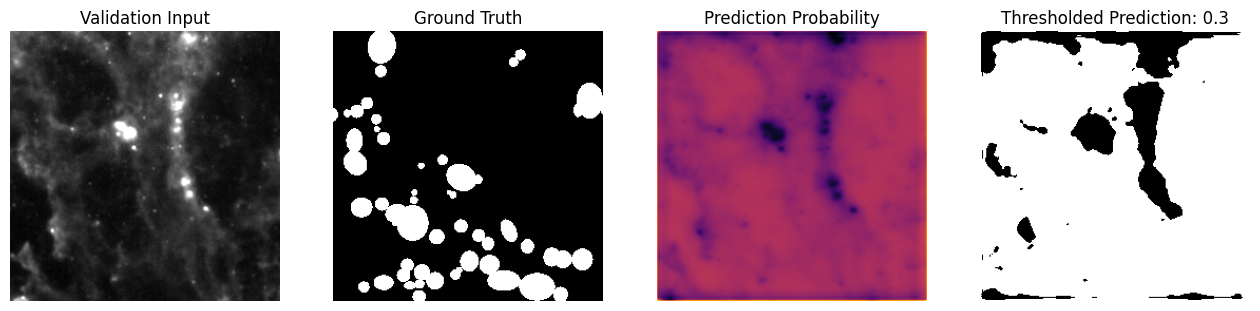

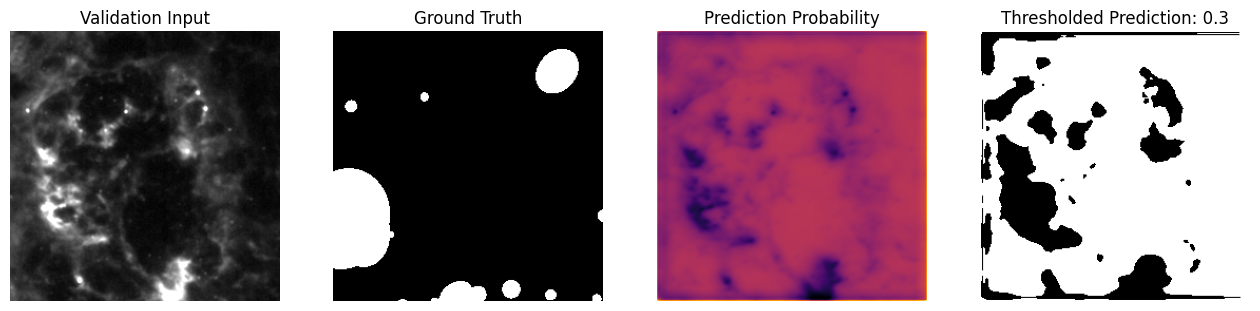

In [22]:
pred = preds_val[idx].squeeze()
pred_thresh = (pred > 0.3).astype(np.float32)

for idx in [0, 5, 10]:

    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(X_val[idx].squeeze(), cmap="gray")
    plt.title("Validation Input")
    plt.axis("off")
    
    plt.subplot(1, 4, 2)
    plt.imshow(Y_val[idx].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")
    
    plt.subplot(1, 4, 3)
    # plt.imshow(pred, cmap="inferno")
    plt.imshow(preds_val[idx].squeeze(), cmap="inferno")
    plt.title("Prediction Probability")
    plt.axis("off")
    
    plt.subplot(1, 4, 4)
    plt.imshow((preds_val[idx].squeeze() > 0.3).astype(np.float32), cmap="gray")
    plt.title("Thresholded Prediction: 0.3")
    plt.axis("off")
    
    plt.show()


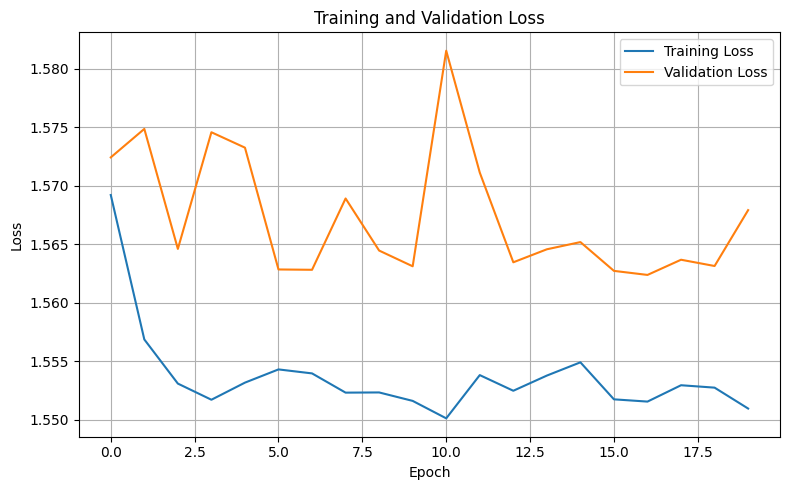

In [23]:
# Loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/loss_curve.png', dpi=300)
plt.show()

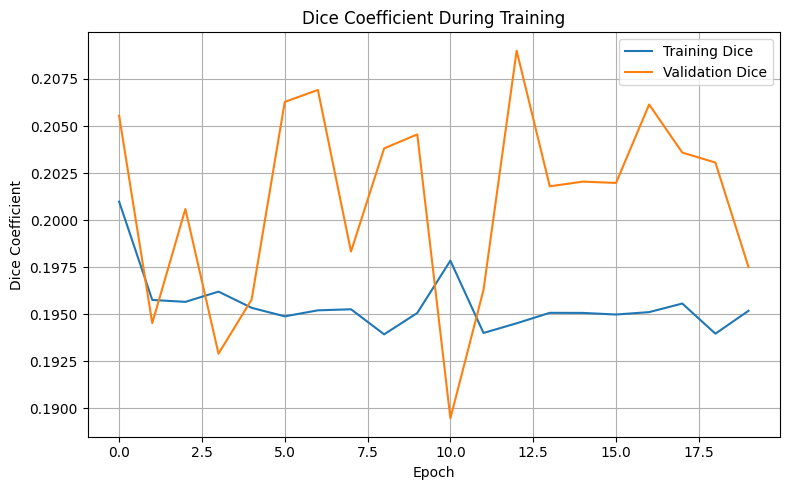

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')

plt.title('Dice Coefficient During Training')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/dice_curve.png', dpi=300)
plt.show()

In [26]:
# Experiment setup
import os
import pandas as pd
from pathlib import Path

EXPERIMENT_DIR = Path("../outputs/experiments")
FIGURE_DIR = Path("../outputs/experiments/figures")
MODEL_DIR = Path("../outputs/experiments/models")

for d in [EXPERIMENT_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Experiment outputs will be saved to:", EXPERIMENT_DIR)


Experiment outputs will be saved to: ../outputs/experiments


In [27]:
## 1. trivial baseline

def binarize(pred, threshold=0.5):
    return (pred > threshold).astype(np.float32)


def dice_np(y_true, y_pred_bin, smooth=1.0):
    y_true = y_true.astype(np.float32)
    y_pred_bin = y_pred_bin.astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    return (2 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred_bin) + smooth)


def iou_np(y_true, y_pred_bin, smooth=1.0):
    y_true = y_true.astype(np.float32)
    y_pred_bin = y_pred_bin.astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    union = np.sum(y_true) + np.sum(y_pred_bin) - intersection
    return (intersection + smooth) / (union + smooth)


def precision_recall_f1_np(y_true, y_pred_bin, smooth=1.0):
    y_true = y_true.astype(np.float32)
    y_pred_bin = y_pred_bin.astype(np.float32)
    tp = np.sum(y_true * y_pred_bin)
    fp = np.sum((1 - y_true) * y_pred_bin)
    fn = np.sum(y_true * (1 - y_pred_bin))
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)
    return precision, recall, f1


def evaluate_binary_prediction(y_true, y_pred_bin, label="model", threshold=None):
    precision, recall, f1 = precision_recall_f1_np(y_true, y_pred_bin)
    gt_area = np.mean(y_true)
    pred_area = np.mean(y_pred_bin)
    area_ratio = pred_area / (gt_area + 1e-8)
    return {
        "label": label,
        "threshold": threshold,
        "dice": dice_np(y_true, y_pred_bin),
        "iou": iou_np(y_true, y_pred_bin),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "gt_foreground_ratio": gt_area,
        "pred_foreground_ratio": pred_area,
        "area_ratio_pred_over_gt": area_ratio,
    }


def threshold_sweep(y_true, y_prob, label="model", thresholds=np.arange(0.05, 0.95, 0.025)):
    rows = []
    for t in thresholds:
        pred_bin = binarize(y_prob, t)
        rows.append(evaluate_binary_prediction(y_true, pred_bin, label=label, threshold=float(t)))
    df = pd.DataFrame(rows)
    return df.sort_values("dice", ascending=False).reset_index(drop=True)


def print_best_threshold(df, top_n=10):
    display(df.head(top_n))
    best = df.iloc[0]
    print(
        f"Best threshold for {best['label']}: {best['threshold']:.3f} | "
        f"Dice={best['dice']:.4f} | IoU={best['iou']:.4f} | "
        f"Precision={best['precision']:.4f} | Recall={best['recall']:.4f} | "
        f"Area ratio={best['area_ratio_pred_over_gt']:.2f}"
    )


In [28]:
# baselines evaluated on the validation set

val_fg_ratio = float(Y_val.mean())

all_background = np.zeros_like(Y_val, dtype=np.float32)
all_foreground = np.ones_like(Y_val, dtype=np.float32)
random_foreground = (np.random.random(Y_val.shape) < val_fg_ratio).astype(np.float32)

baseline_rows = [
    evaluate_binary_prediction(Y_val, all_background, label="all_background", threshold=None),
    evaluate_binary_prediction(Y_val, all_foreground, label="all_foreground", threshold=None),
    evaluate_binary_prediction(Y_val, random_foreground, label="random_matching_fg_ratio", threshold=val_fg_ratio),
]

trivial_baselines_df = pd.DataFrame(baseline_rows)
display(trivial_baselines_df)
trivial_baselines_df.to_csv(EXPERIMENT_DIR / "trivial_baselines.csv", index=False)


,label,threshold,dice,iou,precision,recall,f1,gt_foreground_ratio,pred_foreground_ratio,area_ratio_pred_over_gt
0,all_background,NaN,0.000004,0.000004,1.00000,0.000004,0.000007,0.153089,0.000000,0.000000
1,all_foreground,NaN,0.265529,0.153090,0.15309,1.000000,0.265530,0.153089,1.000000,6.532136
2,random_matching_fg_ratio,0.153089,0.153012,0.082845,0.15327,0.152758,0.153014,0.153089,0.152578,0.996661


In [29]:
## 2: classical image-processing baselines

thresholds = np.arange(0.05, 0.95, 0.025)
classical_rows = []

for t in thresholds:
    bright_pred = (X_val > t).astype(np.float32)
    dark_pred = (X_val < t).astype(np.float32)
    classical_rows.append(evaluate_binary_prediction(Y_val, bright_pred, label="intensity_bright_gt", threshold=float(t)))
    classical_rows.append(evaluate_binary_prediction(Y_val, dark_pred, label="intensity_dark_lt", threshold=float(t)))

classical_df = pd.DataFrame(classical_rows).sort_values("dice", ascending=False).reset_index(drop=True)
display(classical_df.head(15))
classical_df.to_csv(EXPERIMENT_DIR / "classical_intensity_baseline.csv", index=False)


,label,threshold,dice,iou,precision,recall,f1,gt_foreground_ratio,pred_foreground_ratio,area_ratio_pred_over_gt
0,intensity_bright_gt,0.050,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
1,intensity_bright_gt,0.275,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
2,intensity_bright_gt,0.250,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
3,intensity_bright_gt,0.325,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
4,intensity_bright_gt,0.225,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
5,intensity_bright_gt,0.350,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
6,intensity_bright_gt,0.200,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
7,intensity_bright_gt,0.375,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
8,intensity_bright_gt,0.175,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963
9,intensity_bright_gt,0.400,0.275851,0.159993,0.160133,0.994575,0.275851,0.153089,0.950832,6.210963


In [30]:
# Optional classical baseline: smoothed intensity thresholding
# If scipy is unavailable in your environment, this cell will skip gracefully.
try:
    from scipy.ndimage import gaussian_filter

    X_val_smooth = np.zeros_like(X_val)
    for i in range(len(X_val)):
        X_val_smooth[i, ..., 0] = gaussian_filter(X_val[i, ..., 0], sigma=1.0)

    smooth_rows = []
    for t in thresholds:
        bright_pred = (X_val_smooth > t).astype(np.float32)
        dark_pred = (X_val_smooth < t).astype(np.float32)
        smooth_rows.append(evaluate_binary_prediction(Y_val, bright_pred, label="smooth_intensity_bright_gt", threshold=float(t)))
        smooth_rows.append(evaluate_binary_prediction(Y_val, dark_pred, label="smooth_intensity_dark_lt", threshold=float(t)))

    smooth_classical_df = pd.DataFrame(smooth_rows).sort_values("dice", ascending=False).reset_index(drop=True)
    display(smooth_classical_df.head(15))
    smooth_classical_df.to_csv(EXPERIMENT_DIR / "smooth_classical_intensity_baseline.csv", index=False)

except Exception as e:
    print("Skipping smoothed baseline. Reason:", e)


,label,threshold,dice,iou,precision,recall,f1,gt_foreground_ratio,pred_foreground_ratio,area_ratio_pred_over_gt
0,smooth_intensity_bright_gt,0.475,0.276040,0.160120,0.160291,0.993379,0.276041,0.153089,0.948749,6.197358
1,smooth_intensity_bright_gt,0.450,0.276008,0.160098,0.160264,0.993593,0.276008,0.153089,0.949115,6.199750
2,smooth_intensity_bright_gt,0.425,0.275987,0.160084,0.160244,0.993795,0.275987,0.153089,0.949425,6.201776
3,smooth_intensity_bright_gt,0.400,0.275943,0.160055,0.160212,0.993892,0.275943,0.153089,0.949706,6.203609
4,smooth_intensity_bright_gt,0.375,0.275913,0.160035,0.160187,0.994080,0.275914,0.153089,0.950033,6.205749
5,smooth_intensity_bright_gt,0.350,0.275870,0.160006,0.160153,0.994297,0.275871,0.153089,0.950447,6.208450
6,smooth_intensity_bright_gt,0.325,0.275861,0.159999,0.160143,0.994415,0.275861,0.153089,0.950615,6.209550
7,smooth_intensity_bright_gt,0.300,0.275829,0.159978,0.160121,0.994461,0.275829,0.153089,0.950794,6.210718
8,smooth_intensity_bright_gt,0.275,0.275825,0.159976,0.160115,0.994596,0.275826,0.153089,0.950959,6.211792
9,smooth_intensity_bright_gt,0.250,0.275812,0.159966,0.160104,0.994639,0.275812,0.153089,0.951060,6.212455


Selected validation patch indices: [18, 13, 5]
Foreground ratios: [0.16337585 0.22711182 0.1550293 ]


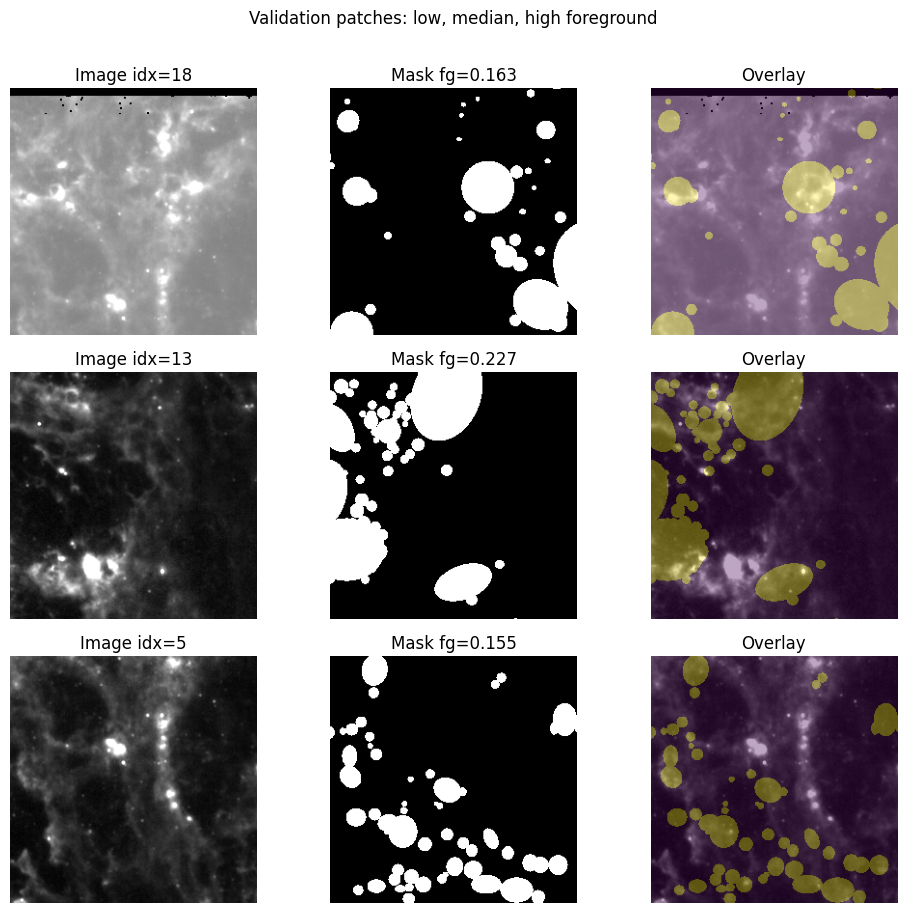

In [37]:
# visual inspection

def plot_patch_grid(X_set, Y_set, indices, title="Patch inspection"):
    n = len(indices)
    plt.figure(figsize=(10, 3 * n))
    for row, idx in enumerate(indices):
        img = X_set[idx].squeeze()
        msk = Y_set[idx].squeeze()

        plt.subplot(n, 3, row * 3 + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Image idx={idx}")
        plt.axis("off")

        plt.subplot(n, 3, row * 3 + 2)
        plt.imshow(msk, cmap="gray")
        plt.title(f"Mask fg={msk.mean():.3f}")
        plt.axis("off")

        plt.subplot(n, 3, row * 3 + 3)
        plt.imshow(img, cmap="gray")
        plt.imshow(msk, alpha=0.35)
        plt.title("Overlay")
        plt.axis("off")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

val_fg_per_patch = Y_val.mean(axis=(1, 2, 3))
low_idx = int(np.argmin(val_fg_per_patch)+2)
mid_idx = int(np.argsort(np.abs(val_fg_per_patch - np.median(val_fg_per_patch)))[0]+2)
high_idx = int(np.argmax(val_fg_per_patch)+2)

selected_indices = [low_idx, mid_idx, high_idx]
print("Selected validation patch indices:", selected_indices)
print("Foreground ratios:", val_fg_per_patch[selected_indices])
plot_patch_grid(X_val, Y_val, selected_indices, title="Validation patches: low, median, high foreground")


Tiny overfit indices: [69 93 78  0  9 81 87 10]
Tiny foreground ratios: [0.34791565 0.35820007 0.38630676 0.40141296 0.41903687 0.43711853
 0.49905396 0.65797424]


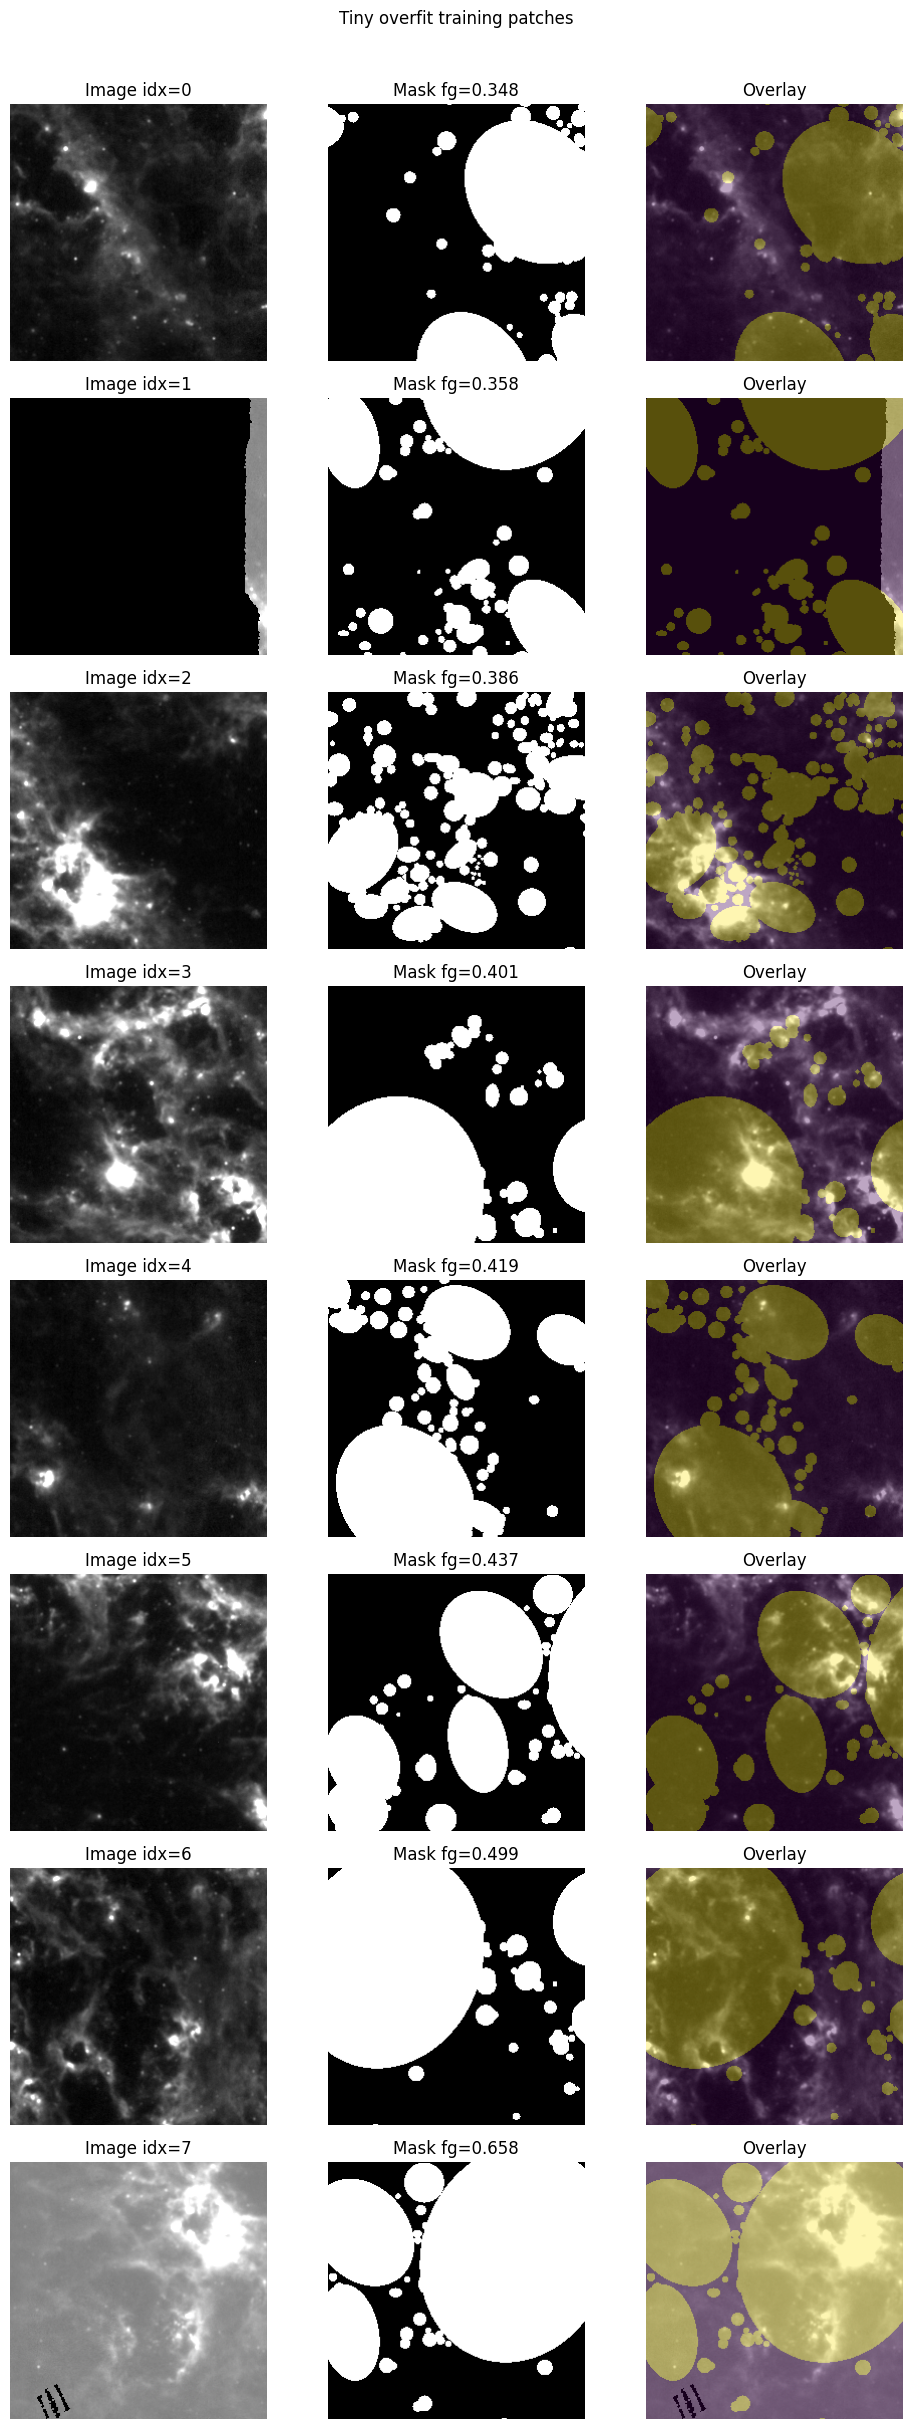

In [38]:
# Select 8 training patches with the highest foreground ratio for the tiny-overfit test
train_fg_per_patch = Y_train.mean(axis=(1, 2, 3))
tiny_indices = np.argsort(train_fg_per_patch)[-8:]
X_tiny = X_train[tiny_indices]
Y_tiny = Y_train[tiny_indices]

print("Tiny overfit indices:", tiny_indices)
print("Tiny foreground ratios:", train_fg_per_patch[tiny_indices])
plot_patch_grid(X_tiny, Y_tiny, list(range(len(X_tiny))), title="Tiny overfit training patches")


In [39]:
# Train the current U-Net on only the tiny subset, without augmentation
# This intentionally overfits. It is a debugging test, not a final model.
tiny_model = build_unet()
tiny_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[dice_coef, iou_coef]
)

tiny_history = tiny_model.fit(
    X_tiny,
    Y_tiny,
    epochs=150,
    batch_size=2,
    verbose=1
)

tiny_preds = tiny_model.predict(X_tiny)
tiny_sweep_df = threshold_sweep(Y_tiny, tiny_preds, label="tiny_overfit_unet", thresholds=np.arange(0.05, 0.95, 0.025))
print_best_threshold(tiny_sweep_df, top_n=10)
tiny_sweep_df.to_csv(EXPERIMENT_DIR / "tiny_overfit_threshold_sweep.csv", index=False)


Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - dice_coef: 0.4655 - iou_coef: 0.3037 - loss: 1.6845
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - dice_coef: 0.4666 - iou_coef: 0.3046 - loss: 1.6807
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - dice_coef: 0.4677 - iou_coef: 0.3056 - loss: 1.6765
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - dice_coef: 0.4690 - iou_coef: 0.3068 - loss: 1.6720
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - dice_coef: 0.4705 - iou_coef: 0.3081 - loss: 1.6668
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - dice_coef: 0.4724 - iou_coef: 0.3096 - loss: 1.6606
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - dice_coef: 0.4746 - iou_coef: 0.3115 - loss: 1.6531
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - dice_coef: 0.4770 - iou_coef: 0.3136 - loss: 1.6451
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - dice_coef: 0.4801 - iou_coef: 0.3164 - loss: 1.6348
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - d

KeyboardInterrupt: 

In [40]:
# Visualize tiny-overfit predictions at the best threshold
best_tiny_threshold = float(tiny_sweep_df.iloc[0]["threshold"])

def plot_predictions(X_set, Y_set, preds, indices, threshold, title="Predictions"):
    n = len(indices)
    plt.figure(figsize=(14, 3 * n))
    for row, idx in enumerate(indices):
        img = X_set[idx].squeeze()
        gt = Y_set[idx].squeeze()
        prob = preds[idx].squeeze()
        pred_bin = (prob > threshold).astype(np.float32)

        plt.subplot(n, 4, row * 4 + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Input {idx}")
        plt.axis("off")

        plt.subplot(n, 4, row * 4 + 2)
        plt.imshow(gt, cmap="gray")
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(n, 4, row * 4 + 3)
        plt.imshow(prob, cmap="inferno")
        plt.title("Probability")
        plt.axis("off")

        plt.subplot(n, 4, row * 4 + 4)
        plt.imshow(pred_bin, cmap="gray")
        plt.title(f"Threshold {threshold:.3f}")
        plt.axis("off")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

plot_predictions(X_tiny, Y_tiny, tiny_preds, list(range(len(X_tiny))), best_tiny_threshold, title="Tiny overfit predictions")


NameError: name 'tiny_sweep_df' is not defined